# LHCb $D_s^+\to\pi^-\pi^+\pi^+$ — Zemach_P real-data fit

This example implements the nominal $D_s^+\to\pi^-\pi^+\pi^+$ amplitude model using the public `main` APIs. The particle ordering is $(\pi^-,\pi^+,\pi^+)$: `s12` and `s13` are the two opposite-sign $\pi^-\pi^+$ combinations and `s23` is the same-sign $\pi^+\pi^+$ combination. Resonances are declared on `pair=(0, 1)` and the second opposite-sign pairing is added automatically by identical-particle symmetrization.

The model uses `Zemach_P()` angular factors, `GounarisSakurai()` for the $\rho(770)^0$, linear QMI interpolation, and `normalize_components=False`. Efficiency and background TH2 maps are evaluated in the historical `s12 × s13` plane. The Gauss–Legendre normalization remains internally parametrized by the fitter in `s13 × s23`, with `s12` reconstructed kinematically.

Reference: LHCb, JHEP 07 (2023) 204, arXiv:2209.09840.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import jax

from dalitzplotfitter import (
    BackgroundSpec,
    DecayChannel,
    DecayModel,
    FitSession,
    GounarisSakurai,
    Parameter,
    QMI,
    RealImag,
    Resonance,
    ToyBackground,
    Zemach_P,
    GooFitLegacyAngular,
    enable_x64,
    generate_toy,
    histogram_background_from_root,
    histogram_efficiency_from_root,
    read_phase_space_sample,
)

enable_x64()
print('JAX backend:', jax.default_backend())
print('JAX devices:', jax.devices())

JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


## 1. Input files and Dalitz convention

The ROOT branches are read without permutation: `s12_pipi_DTF -> s12`, `s13_pipi_DTF -> s13`, and `s23_pipi_DTF -> s23`. Thus `s23` is the same-sign $\pi^+\pi^+$ invariant.

In [2]:
DATA_FILE = Path('/home/jbaptist/work/data/DsPPP_SignalRegion_AllSelectionCuts_Splot_FReweighted_MeanMVA_95.root')
DATA_TREE = 'DecayTree'
S12_BRANCH, S13_BRANCH, S23_BRANCH = 's12_pipi_DTF', 's13_pipi_DTF', 's23_pipi_DTF'
DATA_CUT = None
ENTRY_START, ENTRY_STOP = None, None

EFFICIENCY_FILE = Path('/home/jbaptist/work/data/acc_hist_15_95_Smoothed_normalized.root')
EFFICIENCY_HIST = 'h_eff'
BACKGROUND_FILE = Path('/home/jbaptist/work/data/bkg_hist_15_95_Smoothed.root')
BACKGROUND_HIST = 'h_eff'

SIGNAL_FRACTION = 0.95
NORMALIZATION_BIN_WIDTH = 0.005
RUN_PREFIT_TOY_COMPARISON = True
TOY_SEED = 20230922
RUN_FIT = True

## 2. Published QMI S-wave starting point

The 50 knots below are the central values used as the fit starting point. `QMI(..., interpolation='linear')` linearly interpolates the magnitude and phase parameters in $s=m^2$.

In [3]:
QMI_KNOTS_GEV = np.array([
    0.280,0.390,0.470,0.546,0.623,0.698,0.766,0.819,0.865,0.900,
    0.925,0.942,0.955,0.964,0.972,0.978,0.983,0.990,1.001,1.023,
    1.051,1.083,1.116,1.149,1.179,1.205,1.227,1.245,1.261,1.276,
    1.289,1.302,1.314,1.326,1.338,1.351,1.363,1.375,1.387,1.399,
    1.411,1.424,1.437,1.450,1.465,1.484,1.511,1.554,1.613,1.823,
])
QMI_MAGNITUDE_PAPER = np.array([
    4.54,4.05,4.10,4.41,4.69,4.691,4.994,5.43,6.405,8.096,
    10.624,13.47,16.56,19.45,22.15,24.62,26.95,20.89,13.695,10.995,
    9.593,8.731,7.606,6.961,6.515,6.506,6.264,6.125,6.081,6.071,
    5.912,5.893,5.901,6.031,5.904,6.086,6.181,6.185,6.60,6.63,
    6.90,7.14,7.22,7.56,7.33,7.13,5.009,2.456,2.31,3.75,
])
QMI_PHASE_DEG_PAPER = np.array([
    176.8,152.8,147.6,146.4,149.6,157.4,169.5,-172.8,-152.0,-133.0,
    -116.5,-103.0,-88.8,-74.9,-59.5,-56.7,-21.8,-9.8,5.45,11.28,
    21.57,36.27,48.02,54.42,63.46,63.47,72.45,72.80,77.2,82.2,
    86.1,88.8,93.2,93.8,98.7,103.3,105.7,110.4,114.5,119.7,
    126.5,132.3,142.03,153.74,166.50,-172.15,-136.8,-126.8,-99.5,3.0,
])
QMI_PHASE_RAD_START = np.unwrap(np.deg2rad(QMI_PHASE_DEG_PAPER))
assert len(QMI_KNOTS_GEV) == len(QMI_MAGNITUDE_PAPER) == len(QMI_PHASE_RAD_START) == 50

## 3. Build the amplitude model

The $f_2(1270)$ coefficient is the fixed reference. The QMI contributes 100 floating dynamics parameters and the five other resonances contribute five complex coefficients, for 110 free parameters.

In [4]:
def polar_coefficient(name, magnitude, phase_deg, *, fixed=False):
    phase = np.deg2rad(phase_deg)
    x = float(magnitude * np.cos(phase))
    y = float(magnitude * np.sin(phase))
    if fixed:
        return RealImag(x, y)
    return RealImag(
        Parameter.coefficient(f'{name}.x', x, owner=name, step=0.01),
        Parameter.coefficient(f'{name}.y', y, owner=name, step=0.01),
    )

S_OWNER = 'pipi_S_qmi'
s_magnitudes = tuple(
    Parameter.dynamics(f'S.mag_{i:02d}', float(v), owner=S_OWNER, bounds=(0.0, None), step=max(0.02, 0.01*float(v)))
    for i, v in enumerate(QMI_MAGNITUDE_PAPER)
)
s_phases = tuple(
    Parameter.dynamics(f'S.phase_{i:02d}', float(v), owner=S_OWNER, step=np.deg2rad(1.0))
    for i, v in enumerate(QMI_PHASE_RAD_START)
)
qmi_s_wave = QMI(tuple(QMI_KNOTS_GEV), s_magnitudes, s_phases, interpolation='linear')

coeff = {
    'rho770': polar_coefficient('rho770', 0.1201, 79.4),
    'omega782': polar_coefficient('omega782', 0.04001, -109.9),
    'rho1450': polar_coefficient('rho1450', 1.277, -115.2),
    'rho1700': polar_coefficient('rho1700', 0.873, -60.9),
    'f2_1270': polar_coefficient('f2_1270', 1.0, 0.0, fixed=True),
    'f2p_1525': polar_coefficient('f2p_1525', 0.1098, 178.1),
}

channel = DecayChannel('D_s+', ('pi-', 'pi+', 'pi+'))
angular = GooFitLegacyAngular()
bachelor_momentum_frame="parent"
R_D, R_R = 5.0, 1.5

def resonance(name, coefficient, mass, width, spin, *, lineshape=None):
    kwargs = {} if lineshape is None else {'lineshape': lineshape}
    return Resonance(
        name, (0, 1), coefficient, mass=mass, width=width, spin=spin,
        angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame, **kwargs
    )

model = DecayModel(
    channel,
    [
        Resonance(S_OWNER, (0, 1), RealImag(1.0, 0.0), mass=1.0, width=0.0, spin=0,
                  lineshape=qmi_s_wave, angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame),
        resonance('rho770', coeff['rho770'], 0.77526, 0.1491, 1, lineshape=GounarisSakurai()),
        resonance('omega782', coeff['omega782'], 0.78265, 0.00849, 1),
        resonance('rho1450', coeff['rho1450'], 1.465, 0.400, 1),
        resonance('rho1700', coeff['rho1700'], 1.720, 0.250, 1),
        resonance('f2_1270', coeff['f2_1270'], 1.2755, 0.1867, 2),
        resonance('f2p_1525', coeff['f2p_1525'], 1.5174, 0.086, 2),
    ],
    normalize_components=False,
    normalization_method='gauss-legendre',
    normalization_bin_width=NORMALIZATION_BIN_WIDTH,
)

print('components:', [c.name for c in model.components])
print('free model parameters:', sum(not p.fixed for p in model.parameters))
assert sum(not p.fixed for p in model.parameters) == 110

components: ['pipi_S_qmi', 'rho770', 'omega782', 'rho1450', 'rho1700', 'f2_1270', 'f2p_1525']
free model parameters: 110


## 4. Read data, efficiency and background

The efficiency and background histograms are evaluated on `(s12, s13)`, the two opposite-sign combinations. `s23` remains the same-sign invariant used internally together with `s13` by the Gauss–Legendre grid.

In [5]:
data = read_phase_space_sample(
    DATA_FILE, DATA_TREE,
    s12=S12_BRANCH, s13=S13_BRANCH, s23=S23_BRANCH,
    cut=DATA_CUT, entry_start=ENTRY_START, entry_stop=ENTRY_STOP,
)

efficiency = histogram_efficiency_from_root(
    EFFICIENCY_FILE, EFFICIENCY_HIST, x_variable='s12', y_variable='s13'
)
background = histogram_background_from_root(
    BACKGROUND_FILE, BACKGROUND_HIST, x_variable='s12', y_variable='s13'
)

print(f'Loaded {data.size:,} candidates')
for name in ('s12', 's13', 's23'):
    values = np.asarray(getattr(data, name))
    print(f'{name}: [{values.min():.6g}, {values.max():.6g}] GeV^2')

Loaded 761,684 candidates
s12: [0.0779209, 3.32511] GeV^2
s13: [0.0779476, 3.32737] GeV^2
s23: [0.0779361, 3.33589] GeV^2


## 5. Pre-fit data/toy comparison

This is a direct check that the ROOT branch convention and the model convention agree before running the expensive fit.

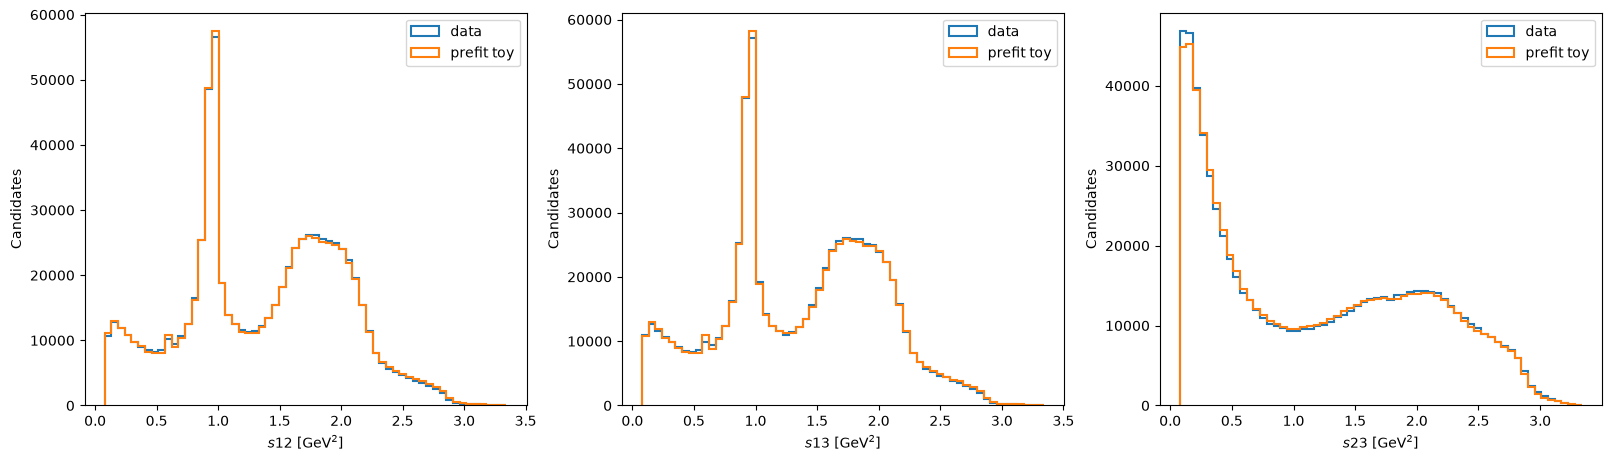

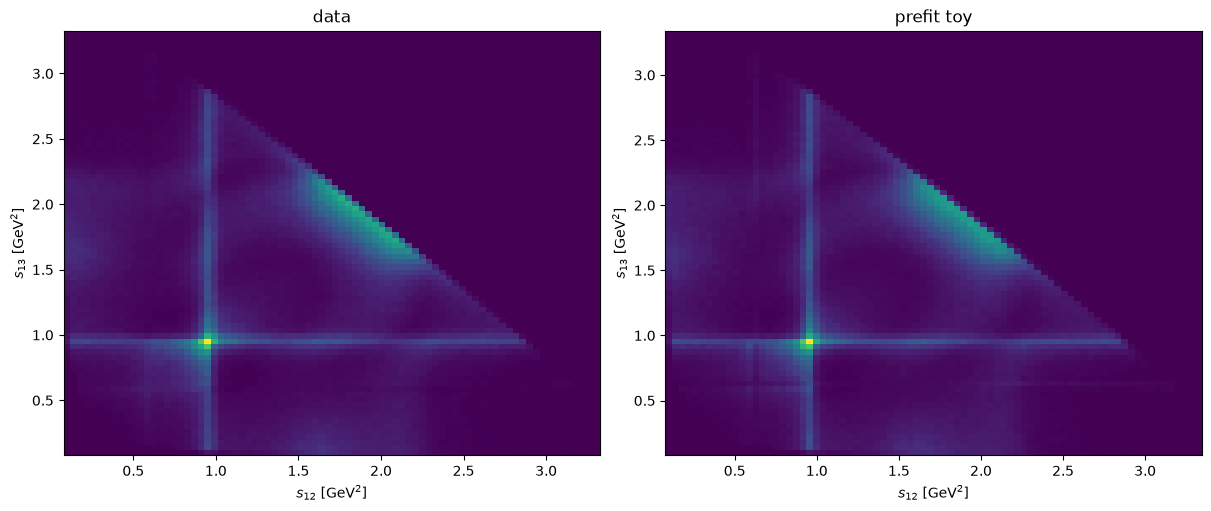

In [6]:
published_start = {p.name: float(p.value) for p in model.parameters if not p.fixed}

if RUN_PREFIT_TOY_COMPARISON:
    prefit_toy = generate_toy(
        model, data.size, parameters=published_start, efficiency=efficiency,
        signal_fraction=SIGNAL_FRACTION,
        backgrounds=(ToyBackground('sideband', background),), seed=TOY_SEED,
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    for ax, variable in zip(axes, ('s12', 's13', 's23')):
        observed = np.asarray(getattr(data, variable))
        generated = np.asarray(getattr(prefit_toy, variable))
        edges = np.linspace(min(observed.min(), generated.min()), max(observed.max(), generated.max()), 61)
        ax.hist(observed, bins=edges, histtype='step', linewidth=1.5, label='data')
        ax.hist(generated, bins=edges, histtype='step', linewidth=1.5, label='prefit toy')
        ax.set(xlabel=rf'${variable}$ [GeV$^2$]', ylabel='Candidates')
        ax.legend()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    axes[0].hist2d(np.asarray(data.s12), np.asarray(data.s13), bins=80)
    axes[0].set(title='data', xlabel=r'$s_{12}$ [GeV$^2$]', ylabel=r'$s_{13}$ [GeV$^2$]')
    axes[1].hist2d(np.asarray(prefit_toy.s12), np.asarray(prefit_toy.s13), bins=80)
    axes[1].set(title='prefit toy', xlabel=r'$s_{12}$ [GeV$^2$]', ylabel=r'$s_{13}$ [GeV$^2$]')
    plt.show()

## 6. Fit

The requested Minuit setup uses strategy 1, no HESSE and no SIMPLEX.

In [ ]:
session = FitSession(
    model, data, efficiency=efficiency, signal_fraction=SIGNAL_FRACTION,
    backgrounds=(BackgroundSpec('sideband', background),),
)

start = dict(published_start)
print('NLL at published start:', float(session.objective(start)))

if RUN_FIT:
    result = session.fit(
        start,
        strategy=1,
        hesse=False,
        simplex=False,
        ncall=250_000,
        tolerance=1e-4,
        verbose=3,
    )

NLL at published start: 937243.9873046319
[Minimizer] single fit with 110 free parameters (simplex=False, strategy=1, hesse=False, ncall=250000, tolerance=0.0001)
I MnSeedGenerator Using analytical (external) gradient calculator but cannot compute G2 - use then numerical gradient for G2
I MnSeedGenerator Computing seed using NumericalGradient calculator


## 7. Fit diagnostics

In [ ]:
if RUN_FIT:
    values = session.result_values(result)
    print('NLL fit:', float(session.objective(values)))
    session.print_fit_fractions(result, acceptance_weighted=False, include_interference=True, precision=4)

    fit_mag = np.array([values[f'S.mag_{i:02d}'] for i in range(50)])
    fit_phase = np.array([values[f'S.phase_{i:02d}'] for i in range(50)])
    paper_complex = QMI_MAGNITUDE_PAPER * np.exp(1j * QMI_PHASE_RAD_START)
    fit_complex = fit_mag * np.exp(1j * fit_phase)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    axes[0].plot(QMI_KNOTS_GEV, QMI_MAGNITUDE_PAPER, 'o', label='paper start')
    axes[0].plot(QMI_KNOTS_GEV, fit_mag, '-', label='fit')
    axes[0].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='magnitude'); axes[0].legend()
    axes[1].plot(QMI_KNOTS_GEV, np.rad2deg(QMI_PHASE_RAD_START), 'o', label='paper start')
    axes[1].plot(QMI_KNOTS_GEV, np.rad2deg(fit_phase), '-', label='fit')
    axes[1].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='phase [deg]'); axes[1].legend()
    axes[2].plot(paper_complex.real, paper_complex.imag, 'o', label='paper start')
    axes[2].plot(fit_complex.real, fit_complex.imag, '-', label='fit')
    axes[2].set(xlabel=r'Re $A_S$', ylabel=r'Im $A_S$'); axes[2].legend()
    plt.show()

    for variable in ('s12', 's13', 's23'):
        session.plot_projection(result, variable, bins=60, projection_size=100_000)
        plt.show()